Generate movie recommendations using the best SVD model

SECTION 1 Setup

In [1]:
!pip install scikit-surprise -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

from surprise import Dataset
from surprise import Reader
from surprise import SVD

from tqdm import tqdm

SECTION 2 Load Data

(Load fixed train-test split)

In [3]:
train_df = pd.read_csv(
    "train_per_user_temporal.csv"
)

test_df = pd.read_csv(
    "test_per_user_temporal.csv"
)

In [4]:
print(train_df.shape)
print(test_df.shape)

(1506935, 4)
(493065, 4)


SECTION 3 Train Best SVD

(Train best performing model)

In [5]:
reader = Reader(
    rating_scale=(1,5)
)

data = Dataset.load_from_df(
    train_df[
        [
            "user_id",
            "movie_id",
            "rating"
        ]
    ],
    reader
)

trainset = data.build_full_trainset()

In [6]:
svd_model = SVD(
    n_factors=100,
    n_epochs=50,
    lr_all=0.003,
    reg_all=0.05,
    random_state=42
)

In [7]:
svd_model.fit(trainset)

SECTION 4 Candidate Movies

(Find unseen movies for recommendation)

Which unseen movies should be recommended to a user?

In [8]:
#Select User
sample_user = train_df[
    "user_id"
].sample(
    1,
    random_state=42
).iloc[0]

sample_user

np.int64(1184954)

In [9]:
#Movies User Already Rated
rated_movies = set(
    train_df[
        train_df["user_id"]
        == sample_user
    ]["movie_id"]
)

In [10]:
# All Movies
all_movies = set(
    train_df["movie_id"]
)

In [11]:
# Unseen Movies
candidate_movies = list(
    all_movies -
    rated_movies
)

print(
    "Candidate Movies:",
    len(candidate_movies)
)

Candidate Movies: 16499


SECTION 5 Predict Ratings

(Estimate user preference for unseen movies)

In [12]:
predictions = []

In [13]:
for movie_id in tqdm(
    candidate_movies
):

    pred = svd_model.predict(
        sample_user,
        movie_id
    )

    predictions.append([
        movie_id,
        pred.est
    ])

100%|██████████| 16499/16499 [00:00<00:00, 147897.16it/s]


In [14]:
recommendations = pd.DataFrame(
    predictions,
    columns=[
        "movie_id",
        "predicted_rating"
    ]
)

SECTION 6 Top 10 Recommendations

(Highest predicted ratings)

In [15]:
top10 = (
    recommendations
    .sort_values(
        "predicted_rating",
        ascending=False
    )
    .head(10)
)

In [16]:
top10

,movie_id,predicted_rating
4181,4427,4.748095
13912,14961,4.700128
6751,7230,4.698475
3257,3446,4.695196
16064,17307,4.683904
4813,5103,4.673487
5396,5760,4.670646
10606,11391,4.666452
13245,14240,4.656248
3267,3456,4.635680


In [27]:
with open(
    "movie_titles.csv",
    "r",
    encoding="latin1"
) as f:

    for i in range(10):
        print(f.readline())

1,2003,Dinosaur Planet

2,2004,Isle of Man TT 2004 Review

3,1997,Character

4,1994,Paula Abdul's Get Up & Dance

5,2004,The Rise and Fall of ECW

6,1997,Sick

7,1992,8 Man

8,2004,What the #$*! Do We Know!?

9,1991,Class of Nuke 'Em High 2

10,2001,Fighter



In [29]:
movies_df = pd.read_csv(
    "movie_titles.csv",
    names=[
        "movie_id",
        "year",
        "title"
    ],
    header=None,
    encoding="latin1",
    engine="python",
    on_bad_lines="skip"
)

In [30]:
movies_df.shape

(17434, 3)

In [31]:
top10_movies = top10.merge(
    movies_df,
    on="movie_id",
    how="left"
)

top10_movies[
    [
        "title",
        "year",
        "predicted_rating"
    ]
].sort_values(
    "predicted_rating",
    ascending=False
)

,title,year,predicted_rating
0,The West Wing: Season 3,2001.0,4.748095
1,Lord of the Rings: The Return of the King: Ext...,2003.0,4.700128
2,The Lord of the Rings: The Fellowship of the R...,2001.0,4.698475
3,Spirited Away,2002.0,4.695196
4,CSI: Season 4,2003.0,4.683904
5,The Simpsons: Season 5,1993.0,4.673487
6,The Sopranos: Season 3,2001.0,4.670646
7,The Work of Director Michel Gondry,2003.0,4.666452
8,Lord of the Rings: The Return of the King,2003.0,4.656248
9,Lost: Season 1,2004.0,4.635680


The recommender prioritizes critically acclaimed and highly popular titles with predicted ratings above 4.6

The model tends to recommend well-known highly-rated content, suggesting popularity effects remain influential.

SECTION 7 Recommendation Statistics

(Analyze recommendation scores)

In [17]:
top10["predicted_rating"].describe()

,predicted_rating
count,10.000000
mean,4.682831
std,0.030535
min,4.635680
25%,4.667500
50%,4.678695
75%,4.697655
max,4.748095


In [18]:
print(
    "Highest Predicted Rating:",
    round(
        top10[
            "predicted_rating"
        ].max(),
        3
    )
)

Highest Predicted Rating: 4.748


SECTION 8 Recommendation Diversity

(Check whether recommendations are concentrated)

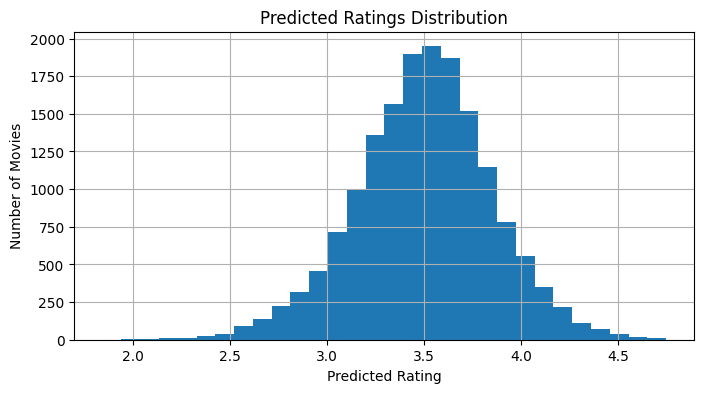

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.hist(
    recommendations["predicted_rating"],
    bins=30
)

plt.title(
    "Predicted Ratings Distribution"
)

plt.xlabel(
    "Predicted Rating"
)

plt.ylabel(
    "Number of Movies"
)

plt.grid(True)

plt.show()

Most predicted ratings are concentrated around 3.0–4.0, with only a small number of movies receiving very high predicted scores.